# Task 1 - Document Inspection Under Uneven Lighting
Three global thresholds are compared with adaptive thresholding.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
img = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Place sudoku.png in the notebook folder.")


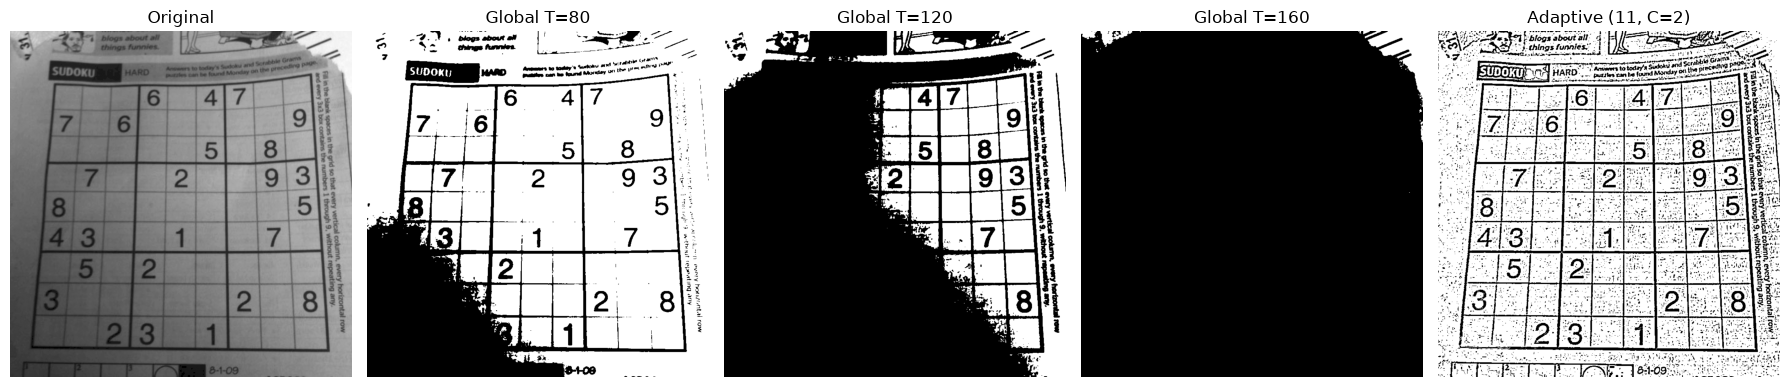

True

In [3]:
# Define threshold values for global thresholding
thresholds = [80, 120, 160]

# Store the thresholded images
globals_ = []

# Apply global thresholding using each threshold value
for t in thresholds:
    _, mask = cv2.threshold(
        img,
        t,
        255,
        cv2.THRESH_BINARY
    )
    globals_.append(mask)

# Apply adaptive Gaussian thresholding
adaptive = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# Create a figure to display all thresholding results
fig, ax = plt.subplots(1, 5, figsize=(18, 5))

# Prepare images and their corresponding titles
items = (
    [("Original", img)]
    + [(f"Global T={t}", mask) for t, mask in zip(thresholds, globals_)]
    + [("Adaptive (11, C=2)", adaptive)]
)

# Display each image
for a, (title, image) in zip(ax, items):
    a.imshow(image, cmap="gray")
    a.set_title(title)
    a.axis("off")

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()

# Save the adaptive thresholding result
cv2.imwrite(str(OUT / "task1_final.png"), adaptive)


## Observation
A single global threshold assumes comparable illumination across the document. Darker areas and brighter areas shift the same foreground/background intensities, so one cutoff can lose characters or include background. Gaussian adaptive thresholding with `blockSize=11, C=2` is selected because it estimates a local threshold and therefore follows uneven illumination.